In [1]:
import pandas as pd
import torch
from torch import nn
from datetime import datetime
import numpy as np
import pickle
from scipy import ndimage
from scipy import interpolate
from matplotlib import pyplot as plt
from Modules import GetRootPath, RadMonitorDataLoader, DiffFluxReconstructor

### Define the geometricMean function to calculate the effective energies of the STEREO-A energy bins

In [2]:
def geometricMean(input: torch.Tensor, dim: int) -> torch.Tensor:
    logInput = torch.log(input)
    return torch.exp(torch.mean(logInput, dim=dim))


### Reading the SEP flux measurements by HET-A in STEREO-A and put them in a Pandas DataFrame

In [3]:
dfHETA = pd.read_csv(f"{GetRootPath()}/Data/STEREO-A/HETA-MayEvt.txt", delimiter=";")
# Format with strptime() behavior
Datetime = pd.to_datetime(
    dfHETA["yearf"].astype(str) + "-" + 
    dfHETA["monthf"].astype(str) + "-" + 
    dfHETA["dayf"].astype(str) + " " + 
    dfHETA["HHMMf"].astype(str).str.zfill(4),
    format="%Y-%b-%d %H%M",
    utc=True
    )
dfHETA.insert(1, "Datetime", Datetime)
dfHETA = dfHETA.set_index("Datetime")
dfHETA = dfHETA.sort_index()
dfIsotropicHETA = dfHETA[(dfHETA.index >= pd.Timestamp(2024, 5, 15, 12, tz="UTC")) & (dfHETA.index < pd.Timestamp(2024, 5, 15, 18, tz="UTC"))]
print(dfIsotropicHETA)

columnsHETA = [
    "p[13.6-15.1]", 
    "p[14.9-17.1]", 
    "p[17.1-20.8]",                              
    "p[20.8-23.8]", 
    "p[23.8-26.4]",
    "p[26.3-29.7]",
    "p[29.5-33.4]",
    "p[33.4-35.8]",
    "p[35.5-40.5]", 
    "p[40-60]",
    "p[60-100]"
]
columnsHETAerr = [
    "p[13.6-15.1]err", 
    "p[14.9-17.1]err", 
    "p[17.1-20.8]err",                              
    "p[20.8-23.8]err", 
    "p[23.8-26.4]err",
    "p[26.3-29.7]err",
    "p[29.5-33.4]err",
    "p[33.4-35.8]err",
    "p[35.5-40.5]err", 
    "p[40-60]err",
    "p[60-100]err"
]
energiesMeasuredHETA = torch.tensor([
    [13.6, 15.1],
    [14.9, 17.1],
    [17.1, 20.8],
    [20.8, 23.8],
    [23.8, 26.4],
    [26.3, 29.7],
    [29.5, 33.4],
    [33.4, 35.8],
    [35.5, 40.5],
    [40, 60],
    [60, 100],
])
energiesMeasuredHETA = geometricMean(energiesMeasuredHETA, dim=1)
print(energiesMeasuredHETA)

                           listifile  yeari monthi  dayi  HHMMi  yearf monthf  \
Datetime                                                                        
2024-05-15 12:00:00+00:00          0   2024    May    15   1145   2024    May   
2024-05-15 12:15:00+00:00          0   2024    May    15   1200   2024    May   
2024-05-15 12:30:00+00:00          0   2024    May    15   1215   2024    May   
2024-05-15 12:45:00+00:00          0   2024    May    15   1230   2024    May   
2024-05-15 13:00:00+00:00          0   2024    May    15   1245   2024    May   
2024-05-15 13:15:00+00:00          0   2024    May    15   1300   2024    May   
2024-05-15 13:30:00+00:00          0   2024    May    15   1315   2024    May   
2024-05-15 13:45:00+00:00          0   2024    May    15   1330   2024    May   
2024-05-15 14:00:00+00:00          0   2024    May    15   1345   2024    May   
2024-05-15 14:15:00+00:00          0   2024    May    15   1400   2024    May   
2024-05-15 14:30:00+00:00   


### Reading the SEP flux measurements by LET-A in STEREO-A and put them in a Pandas DataFrame

In [4]:
columnsLETA = [
    "4.0-4.5 MeV proton flux [1/(cm^2 s sr MeV/nuc)]",
    "4.5-5.0 MeV proton flux [1/(cm^2 s sr MeV/nuc)]",
    "5.0-6.0 MeV proton flux [1/(cm^2 s sr MeV/nuc)]",
    "6.0-8.0 MeV proton flux [1/(cm^2 s sr MeV/nuc)]",
    "8.0-10.0 MeV proton flux [1/(cm^2 s sr MeV/nuc)]",
    "10.0-12.0 MeV proton flux [1/(cm^2 s sr MeV/nuc)]",
]

dates = []
data = [] 
with open(f"{GetRootPath()}/Data/STEREO-A/OmniLET.txt", "r") as filehandler:
    while True:
        buffer = filehandler.readline()
        if not buffer or buffer.strip() == "BEGIN DATA":
            break
    
    while True:
        buffer = filehandler.readline()
        if not buffer:
            break

        bufferData = buffer.split()
        dates.append(pd.to_datetime(f"{bufferData[0]}-{int(float(bufferData[1]))}-{bufferData[2]}", format="%Y-%j-%H", utc=True))
        rowData = [float(bufferData[i+11]) for i in range(len(columnsLETA))]
        data.append(rowData)
        
# Storing the differential flux data read from the file in a pandas DataFrame
dfLETA = pd.DataFrame(columns=columnsLETA, index=dates, data=data)
dfIsotropicLETA = dfLETA[(dfLETA.index >= pd.Timestamp(2024, 5, 15, 12, tz="UTC")) & (dfLETA.index < pd.Timestamp(2024, 5, 15, 18, tz="UTC"))]
print(dfIsotropicLETA)

energiesMeasuredLETA = torch.tensor([
    [4.0, 4.5],
    [4.5, 5.0],
    [5.0, 6.0],
    [6.0, 8.0],
    [8.0, 10.0],
    [10.0, 12.0],
])
energiesMeasuredLETA = geometricMean(energiesMeasuredLETA, dim=1)
print(energiesMeasuredLETA)

                           4.0-4.5 MeV proton flux [1/(cm^2 s sr MeV/nuc)]  \
2024-05-15 12:00:00+00:00                                           41.924   
2024-05-15 13:00:00+00:00                                           34.806   
2024-05-15 14:00:00+00:00                                           31.486   
2024-05-15 15:00:00+00:00                                           30.129   
2024-05-15 16:00:00+00:00                                           28.639   
2024-05-15 17:00:00+00:00                                           27.788   

                           4.5-5.0 MeV proton flux [1/(cm^2 s sr MeV/nuc)]  \
2024-05-15 12:00:00+00:00                                           35.165   
2024-05-15 13:00:00+00:00                                           29.424   
2024-05-15 14:00:00+00:00                                           26.807   
2024-05-15 15:00:00+00:00                                           25.676   
2024-05-15 16:00:00+00:00                                      

### Loading the count rate data measured by RADEM during the isotropic proton flux period

                           PROTONS_1  PROTONS_3  PROTONS_4  PROTONS_5  \
2024-05-15 12:00:00+00:00   3.294444   1.260000   0.582222   0.357778   
2024-05-15 12:15:00+00:00   3.290000   1.208889   0.507778   0.341111   
2024-05-15 12:30:00+00:00   3.276667   1.225556   0.498889   0.353333   
2024-05-15 12:45:00+00:00   3.280000   1.218889   0.497778   0.351111   
2024-05-15 13:00:00+00:00   3.298889   1.155556   0.526667   0.351111   
2024-05-15 13:15:00+00:00   3.118889   1.152222   0.506667   0.350000   
2024-05-15 13:30:00+00:00   3.138889   1.140000   0.450000   0.362222   
2024-05-15 13:45:00+00:00   3.206667   1.154444   0.500000   0.346667   
2024-05-15 14:00:00+00:00   3.110000   1.115556   0.491111   0.340000   
2024-05-15 14:15:00+00:00   3.208889   1.088889   0.464444   0.358889   
2024-05-15 14:30:00+00:00   3.280000   1.171111   0.475556   0.317778   
2024-05-15 14:45:00+00:00   3.163333   1.194444   0.463333   0.317778   
2024-05-15 15:00:00+00:00   3.294444   1.096667   0

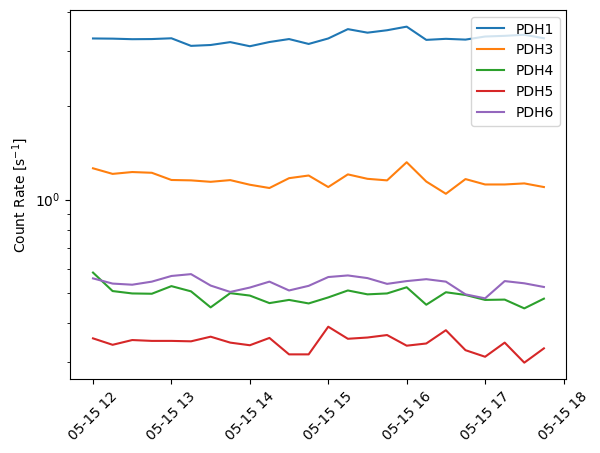

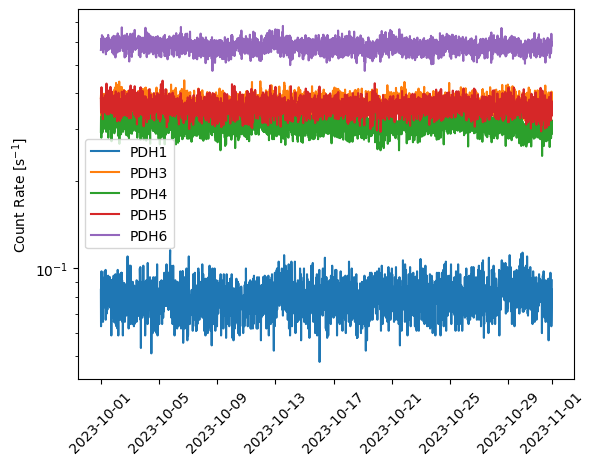

Bkg Mean
PROTONS_1    0.080056
PROTONS_3    0.369769
PROTONS_4    0.312122
PROTONS_5    0.359193
PROTONS_6    0.579941
dtype: float64
-----------------------------------------
Bkg Standard Deviation
PROTONS_1    0.009680
PROTONS_3    0.021074
PROTONS_4    0.019203
PROTONS_5    0.020869
PROTONS_6    0.027032
dtype: float64
-----------------------------------------


In [5]:
keys = ["PROTONS"]
timeStep = 15 # Minutes
# Defining the time interval of the loaded count rates
dateSEP = [datetime(year=2024, month=5, day=15, hour=12), datetime(year=2024, month=5, day=15, hour=18)]

# Creating a RadMonitorDataLoader object and use it to load the PDH count rates into a pandas DataFrame
dataSEPLoader = RadMonitorDataLoader()
dataSEPLoader.LoadCDFFiles(keys, *dateSEP)

#####################################################################################
# Loading the count rates used by the machine learning model into a pandas DataFrame
#####################################################################################
# Choosing the detection bins that are used by the model
detectionBinList = [1, 3, 4, 5, 6]
detectionBinNameList = [f"PROTONS_{detectionBin}" for detectionBin in detectionBinList]
dataSEP = dataSEPLoader.dataFrames["PROTONS"]
# Re-binning the count rates to 1 point every 15 minutes
dataSEP = dataSEP.resample(f"{timeStep}min").mean()
# From counts/min to counts/sec
dataSEP = dataSEP.div(60)
dataSEP = dataSEP.loc[:, detectionBinNameList]
print(dataSEP)
# Plotting the RADEM count rate data
for i, column in enumerate(dataSEP.columns):
    plt.plot(dataSEP.index, dataSEP[column], label=f"PDH{detectionBinList[i]}")
    plt.xticks(rotation=45)
    plt.yscale("log")
plt.ylabel(r"Count Rate [s$^{-1}$]")
plt.legend()
plt.show()

##############################################################################
# Loading the count rates used bow tie reconstruction into a pandas DataFrame
##############################################################################
# Choosing the detection bins for the detectionBin combinations used for the bow tie technique
detectionBinListBowTie = [1, 2, 3, 4, 5]
detectionBinNameListBowTie = [f"PROTONS_{detectionBin}" for detectionBin in detectionBinListBowTie]
dataSEPBowTie = dataSEPLoader.dataFrames["PROTONS"]
# Re-bin the count rates to 1 point every 15 minutes
dataSEPBowTie = dataSEPBowTie.resample(f"{timeStep}min").mean()
# From counts/min to counts/sec
dataSEPBowTie = dataSEPBowTie.div(60)
dataSEPBowTie = dataSEPBowTie.loc[:, detectionBinNameListBowTie]
# Removing the spikes in the PDH2 count rates
dataSEPBowTie["PROTONS_2"] = ndimage.median_filter(dataSEPBowTie["PROTONS_2"], size=3)
# Reading measured count rates in a time period where no SEP event was measured by RADEM to serve as background

dataBkgLoader = RadMonitorDataLoader()
dataBkgLoader.LoadCDFFiles(keys, datetime(2023, 10, 1), datetime(2023, 11, 1))
dataBkgProtons = dataBkgLoader.dataFrames["PROTONS"]
# dataBkg is used for ensemble selection
dataBkg = dataBkgProtons.loc[:, detectionBinNameList]
dataBkg = dataBkg.resample(f"{timeStep}min").mean()
dataBkg = dataBkg.div(60)
# PDH2Bkg is used exclusively for the bow tie reconstruction
PDH2Bkg = dataBkgProtons.loc[:, "PROTONS_2"]
PDH2Bkg = PDH2Bkg.resample(f"{timeStep}min").mean()
PDH2Bkg = PDH2Bkg.div(60)

# Plotting the background
for i, column in enumerate(dataBkg.columns):
    plt.plot(dataBkg.index, dataBkg[column], label=f"PDH{detectionBinList[i]}")
    plt.xticks(rotation=45)
    plt.yscale("log")
plt.ylabel(r"Count Rate [s$^{-1}$]")
plt.legend()
plt.show()

bkgMean = dataBkg.mean(axis=0)
bkgStd = dataBkg.std(axis=0)
bkgMeanPDH2 = PDH2Bkg.mean(axis=0)
bkgStdPDH2 = PDH2Bkg.std(axis=0)
print("Bkg Mean")
print(bkgMean)
print("-----------------------------------------")
print("Bkg Standard Deviation")
print(bkgStd)
print("-----------------------------------------")
bkgMean = torch.tensor(bkgMean.to_numpy(), dtype=torch.float32)
bkgStd = torch.tensor(bkgStd.to_numpy(), dtype=torch.float32)

# Partially removing the background from the count rates used by the machine learning model
countRates = torch.tensor(dataSEP.to_numpy(), dtype=torch.float32)
countRates = countRates - bkgMean + 6*bkgStd

# Removing the background in PDH2
dataSEPBowTie["PROTONS_2"] = dataSEPBowTie["PROTONS_2"] - bkgMeanPDH2

### Differential flux spectrum comparison plot used in the Article 

tensor([1.0794e-02, 8.0869e-03, 6.6168e-03, 4.2666e-03, 3.7994e-03, 2.8142e-03,
        2.1400e-03, 2.1980e-03, 1.2040e-03, 3.2493e-04, 6.1878e-05])
tensor([32.5544, 35.3518, 21.4579, 14.5822,  2.1854,  6.5270,  9.0129,  7.4921,
         4.2865,  9.5293,  8.7950, 10.4222, 10.1515, 17.3077, 25.2273, 30.2540,
        29.5643])


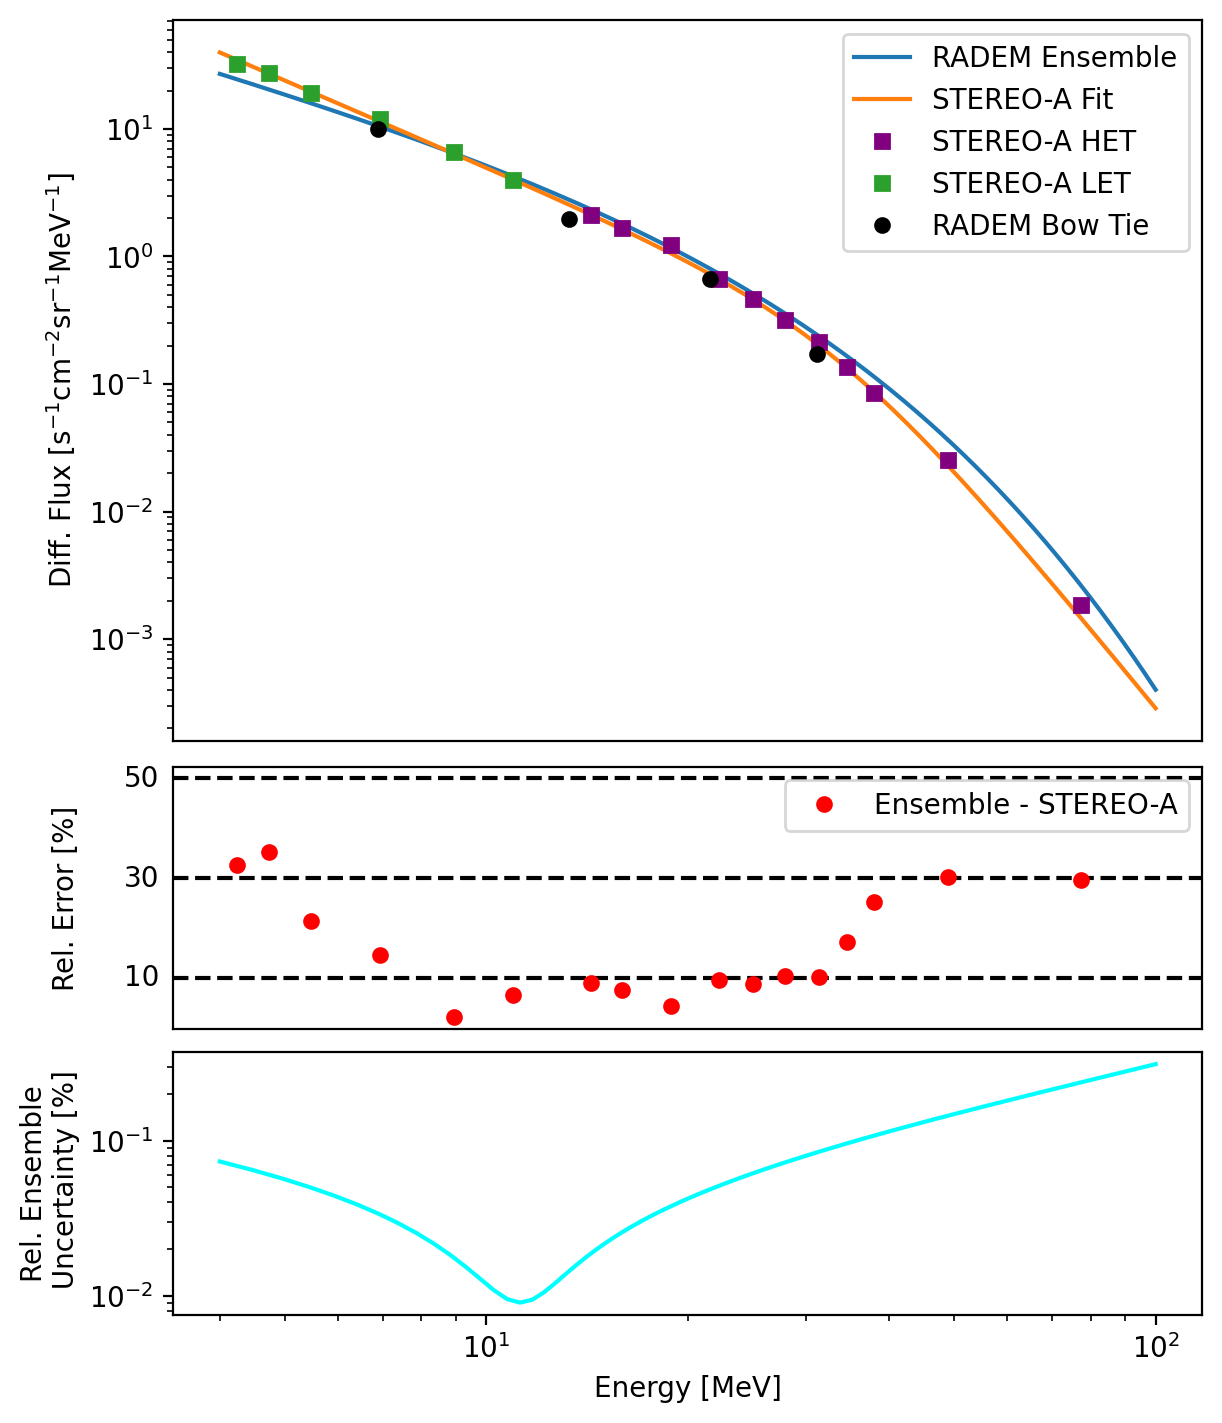

In [6]:
##########################################
# RADEM Deep Ensembles Reconstructed Flux
##########################################
yLabels = [r"Intensity [cm$^{-2}$s$^{-1}$sr$^{-1}$MeV$^{-1}$]", "Spectral Index", "Rollover Energy [MeV]"]
targetLabels = ["Intensity", "SpectralIndex", "RolloverEnergy"]
# Creating a count rates torch tensor
diffFluxReconstructor = DiffFluxReconstructor()
# Using the machine learning model (DiffFluxReconstructor object) to reconstruct the differential flux spectra
# from the measured count rates, with a partial background removal
# 6 * bkgStd are the new bkg means of the detection bins after the background reduction, used for ensemble selection
predParameters, predParameterUncertainties, predParameterSamples, maskDict = diffFluxReconstructor(countRates, bkgMean=6*bkgStd)
# Define the energy range for which the reconstructed differetial flux spectrum is calculated
energies = torch.linspace(4, 100, 200)
reconstructedFluxSamples = predParameterSamples[:, 0, :].unsqueeze(-1) * diffFluxReconstructor.RollingPowerLaw(energies, predParameterSamples[:, 1:, :])


###################################
# RADEM Bow Tie Reconstructed Flux
###################################
effectiveEnergies = torch.tensor([6.9, 13.3, 21.6, 31.2])
geometricFactors = torch.tensor([0.214, 0.837, 1.22, 0.844])
combinedDetectionBinsBowTie = torch.tensor(np.array([
    (dataSEPBowTie["PROTONS_1"] - dataSEPBowTie["PROTONS_3"]).values,
    (dataSEPBowTie["PROTONS_2"] - dataSEPBowTie["PROTONS_4"]).values,
    (dataSEPBowTie["PROTONS_3"] - dataSEPBowTie["PROTONS_5"]).values,
    (dataSEPBowTie["PROTONS_4"] - dataSEPBowTie["PROTONS_5"]).values
])).transpose(0, 1)
reconstructedFluxBowTie = combinedDetectionBinsBowTie / geometricFactors.unsqueeze(0)

################################
# STEREO-A Broken Power Law Fit
################################
gamma1 = 2.26
gamma2 = 6.46
alpha = 3.73
Eb = 33.9 #MeV
E0 = 0.1 # MeV
I0 = 1.66e+5 # s^-1 cm^-2 sr^-1 MeV^-1 
BPLfit = I0 * torch.pow(energies/E0, -gamma1) * torch.pow((torch.pow(energies, alpha) + torch.pow(torch.tensor(Eb), alpha).unsqueeze(-1)) / (torch.pow(torch.tensor(E0), alpha) + torch.pow(torch.tensor(Eb), alpha)).unsqueeze(-1), (gamma1-gamma2)/alpha)

###########################################################################
# Selecting the STEREO-A measurements for the differential flux comparison
###########################################################################
measuredFluxHETA = torch.tensor(dfIsotropicHETA[columnsHETA].values, dtype=torch.float32)
measuredFluxHETAerr = torch.tensor(dfIsotropicHETA[columnsHETAerr].values, dtype=torch.float32)
measuredFluxLETA = torch.tensor(dfIsotropicLETA[columnsLETA].values, dtype=torch.float32)

# RADEM Reconstructed time-averaged flux with Deep Ensembles
averagedReconstructedFluxSamples = torch.mean(reconstructedFluxSamples, dim=0)
averagedReconstructedFlux = torch.mean(averagedReconstructedFluxSamples, dim=0)
averagedReconstructedFluxUncertainties = torch.std(averagedReconstructedFluxSamples, dim=0)

# RADEM Reconstructed time-averaged flux with Bow Tie
averagedBowTieFlux = torch.mean(reconstructedFluxBowTie, dim=0)
# HET-A Measured time-averaged flux
averagedMeasuredFluxHETA = torch.mean(measuredFluxHETA, dim=0)
averagedMeasuredFluxHETAerr = torch.norm(measuredFluxHETAerr, dim=0)/measuredFluxHETAerr.shape[0]
print(averagedMeasuredFluxHETAerr) # Errors are too small to appear in the plot
# LET-A OMNI Measured time-averaged flux
averagedMeasuredFluxLETA = torch.mean(measuredFluxLETA, dim=0)

# RADEM Reconstructed time-averaged flux with Deep Ensembles for direct comparison with STEREO-A measruements
averagedMeasuredFluxSTEREOA = torch.cat((averagedMeasuredFluxLETA, averagedMeasuredFluxHETA))
energiesSTEREOA = torch.cat((energiesMeasuredLETA, energiesMeasuredHETA))
reconstructedFluxSamples_STEREOA = predParameterSamples[:, 0, :].unsqueeze(-1) * diffFluxReconstructor.RollingPowerLaw(energiesSTEREOA, predParameterSamples[:, 1:, :])
averagedReconstructedFlux_STEREOA= torch.mean(reconstructedFluxSamples_STEREOA, dim=(0, 1))

####################################
# Differential Flux Comparison Plot
####################################
fig = plt.figure(figsize=(6, 7), dpi=200, constrained_layout=True)
gridSpec = fig.add_gridspec(3, 1, hspace=0.05, wspace=0, height_ratios=[5.5, 2, 2])
(axDiffFlux, axResiduals1, axResiduals2) = gridSpec.subplots(sharex='col')

axDiffFlux.plot(energies, averagedReconstructedFlux, label="RADEM Ensemble")
axDiffFlux.plot(energies, BPLfit, label="STEREO-A Fit")
axDiffFlux.plot(energiesMeasuredHETA, averagedMeasuredFluxHETA, marker="s", ms=5, ls="", color="purple", label="STEREO-A HET")
axDiffFlux.plot(energiesMeasuredLETA, averagedMeasuredFluxLETA, marker="s", ms=5, ls="", label="STEREO-A LET")
axDiffFlux.plot(effectiveEnergies, averagedBowTieFlux, marker="o", ms=5, ls="", color="black", label="RADEM Bow Tie")
axDiffFlux.set_ylabel(r"Diff. Flux [s$^{-1}$cm$^{-2}$sr$^{-1}$MeV$^{-1}$]")
axDiffFlux.set_yscale("log")
axDiffFlux.set_xscale("log")
axDiffFlux.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
axDiffFlux.legend()

relativeError_Ensemble_STEREOA = torch.abs(averagedMeasuredFluxSTEREOA - averagedReconstructedFlux_STEREOA)/averagedReconstructedFlux_STEREOA*100
print(relativeError_Ensemble_STEREOA)
thresholds = [10, 30, 50]
for threshold in thresholds:
    axResiduals1.axhline(y=threshold, color="black", linestyle="--", linewidth=1.5)
    axResiduals1.annotate(
        f"{threshold}", xy=(0, threshold), xycoords=("axes fraction", "data"),  # x = 0 -> Left edge of axes
        xytext=(-5, 0), textcoords="offset points",  # Shift 5 points to the right
        va="center", ha="right", color="black", fontsize=10
    )
axResiduals1.plot(energiesSTEREOA, relativeError_Ensemble_STEREOA, marker="o", ms=5, ls="", color="red", label="Ensemble - STEREO-A")
axResiduals1.set_ylabel("Rel. Error [%]")
axResiduals1.yaxis.set_label_coords(x=-0.09, y=0.5)
axResiduals1.tick_params(axis="y", which="both", left=False, labelleft=False)
axResiduals1.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
axResiduals1.legend()

relativeEnsembleUncertainty = averagedReconstructedFluxUncertainties/averagedReconstructedFlux*100
axResiduals2.plot(energies, relativeEnsembleUncertainty, color="cyan")
axResiduals2.set_ylabel("Rel. Ensemble\n Uncertainty [%]")
axResiduals2.set_xlabel("Energy [MeV]")
axResiduals2.yaxis.set_label_coords(x=-0.09, y=0.5)
axResiduals2.set_yscale("log")
plt.show()      

#### Calculating the relative errors of the reconstructed spectra with the Deep Ensembles and Bow Tie, with respect to the STEREO-A Measurements

In [7]:
# Calculating the Broken Power Law fit of the STEREO-A differntial flux measurements for the energies of the bow tie combined detectionBins
BPLfit_BowTieEnergies = I0 * torch.pow(effectiveEnergies/E0, -gamma1) * torch.pow((torch.pow(effectiveEnergies, alpha) + torch.pow(torch.tensor(Eb), alpha).unsqueeze(-1)) / (torch.pow(torch.tensor(E0), alpha) + torch.pow(torch.tensor(Eb), alpha)).unsqueeze(-1), (gamma1-gamma2)/alpha)
reconstructedFluxSamples_BowTieEnergies = predParameterSamples[:, 0, :].unsqueeze(-1) * diffFluxReconstructor.RollingPowerLaw(effectiveEnergies, predParameterSamples[:, 1:, :])
averagedReconstructedFlux_BowTieEnergies = torch.mean(reconstructedFluxSamples_BowTieEnergies, dim=(0, 1))

print(effectiveEnergies)
print(torch.abs(averagedReconstructedFlux_BowTieEnergies - BPLfit_BowTieEnergies)/BPLfit_BowTieEnergies * 100)
print(torch.abs(averagedBowTieFlux - BPLfit_BowTieEnergies)/BPLfit_BowTieEnergies * 100)

tensor([ 6.9000, 13.3000, 21.6000, 31.2000])
tensor([ 8.9665,  9.4370, 10.4594, 18.0694])
tensor([13.4475, 22.8681,  8.0987, 16.0034], dtype=torch.float64)
